In [1]:
import pandas as pd

# 2 pandas dataframe

In [7]:
df = pd.read_csv('state_data.csv')
df

,state,latitude,longitude,name
0,AK,63.588753,-154.493062,Alaska
1,AL,32.318231,-86.902298,Alabama
2,AR,35.201050,-91.831833,Arkansas
3,AZ,34.048928,-111.093731,Arizona
4,CA,36.778261,-119.417932,California
5,CO,39.550051,-105.782067,Colorado
6,CT,41.603221,-73.087749,Connecticut
7,DC,38.905985,-77.033418,District of Columbia
8,DE,38.910832,-75.527670,Delaware
9,FL,27.664827,-81.515754,Florida


In [9]:
df.shape
# there are 52 rows and 4 columns

(52, 4)

In [13]:
print(df.head())
print(df.tail())
# the different columns represent
# different details of each of the states
# including its abbreviation, latitude,
# longitude, and name.

# the first state in the dataset is arkansas,
# and the last is wyoming

# there are more than 50 states listed
# because the dataset probably considers different territories like
# d.c., puerto rico, etc.

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


In [15]:
median_lat = df["latitude"].median()
median_long = df["longitude"].median()

print(median_lat)
print(median_long)

# the median latitude is 39.44 degrees
# the median longitude is -89.09 degrees

39.4355155
-89.093198


In [19]:
# 7 - absolute value distance to median lat
df['latitude_dist'] = (df['latitude'] -median_lat).abs()
print(df.head()[['latitude', 'latitude_dist']]) 

    latitude  latitude_dist
0  63.588753      24.153237
1  32.318231       7.117285
2  35.201050       4.234465
3  34.048928       5.386588
4  36.778261       2.657255


In [21]:
# 8 absolute value distance to median long

df['longitude_dist'] = (df['longitude'] - median_long).abs()
print(df.head()[["longitude", "longitude_dist"]])

    longitude  longitude_dist
0 -154.493062       65.399864
1  -86.902298        2.190900
2  -91.831833        2.738635
3 -111.093731       22.000533
4 -119.417932       30.324734


In [24]:
# 9 shape w/ new column
new_shape = df.shape
new_shape
# now we have 52 rows and 6 columns

(52, 6)

In [37]:
# 10
#closest to median latitude
closest_lat = df.loc[df['latitude_dist'].idxmin()]
print(f"closest to median latitude: {closest_lat['name']} by {closest_lat['latitude_dist']:.2f}")

# farthest from median latitude
farthest_lat = df.loc[df['latitude_dist'].idxmax()]
print(f"farthest from median latitude: {farthest_lat['name']} by {farthest_lat['latitude_dist']:.2f}")

# closest to median long
closest_lon = df.loc[df['longitude_dist'].idxmin()]
print(f"Closest to Median Longitude: {closest_lon['name']} by {closest_lon['longitude_dist']:.2f}")

# 10. Farthest from median longitude
farthest_lon = df.loc[df['longitude_dist'].idxmax()]
print(f"Farthest from Median Longitude: {farthest_lon['name']} by {farthest_lon['longitude_dist']:.2f}")
print("-" * 30)

closest to median latitude: Colorado by 0.11
farthest from median latitude: Alaska by 24.15
Closest to Median Longitude: Illinois by 0.31
Farthest from Median Longitude: Hawaii by 66.57
------------------------------


In [41]:
print("--- 1. Top 10 Northernmost States (Highest Latitude) ---")
top_10_lat = df.nlargest(10, 'latitude')

print(top_10_lat[['name', 'latitude']])
print("\n" + "-" * 45)


print("--- 2. 5 Westernmost States (Smallest Longitude) ---")
bottom_5_lon = df.nsmallest(5, 'longitude')

print(bottom_5_lon[['name', 'longitude']])
print("-" * 45)

# .nlargest and .nsmallest are functions that help easily retrieve the top
# or bottom N rows of a dataframe based on specific columns

--- 1. Top 10 Northernmost States (Highest Latitude) ---
            name   latitude
0         Alaska  63.588753
48    Washington  47.751074
28  North Dakota  47.551493
26       Montana  46.879682
23     Minnesota  46.729553
21         Maine  45.253783
47       Vermont  44.558803
22      Michigan  44.314844
13         Idaho  44.068202
42  South Dakota  43.969515

---------------------------------------------
--- 2. 5 Westernmost States (Smallest Longitude) ---
          name   longitude
11      Hawaii -155.665857
0       Alaska -154.493062
48  Washington -120.740139
37      Oregon -120.554201
4   California -119.417932
---------------------------------------------


# 3 seaborn

In [47]:
import seaborn as sns

In [56]:
df_flights = sns.load_dataset("flights")
df_flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [60]:
# 5 dropping columns w/ NaN values
df_clean = df_flights.dropna(axis=1)
df_clean

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [64]:
# 6 analyzing the dataset
df_clean.shape
# there are 144 rows and 3 columns
print(df_clean.head())
print(df_clean.tail())

# the column names are:
# year: the year that the flight took place
# month: the month that the flight took place
# passengers: the number of passengers on
# the flight in that row

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
     year month  passengers
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432


In [65]:
import matplotlib.pyplot as plt

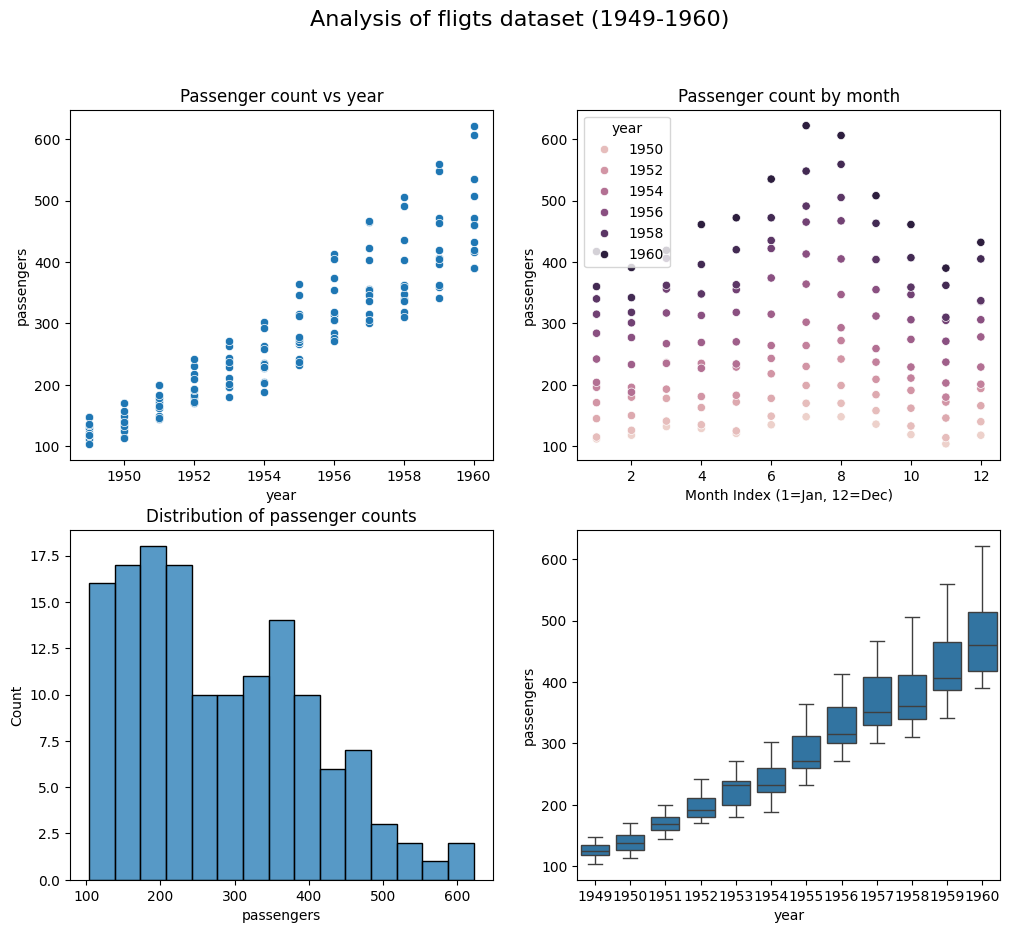

In [75]:
# 7 creating custom subplots

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Analysis of fligts dataset (1949-1960)", fontsize=16)

# top left
sns.scatterplot(
    data = df_clean,
    x = 'year',
    y = 'passengers',
    ax = axes[0,0]
)
axes[0,0].set_title("Passenger count vs year")

# top right
df_clean['month_num'] = df_clean['month'].astype('category').cat.codes + 1
sns.scatterplot(
    data=df_clean,
    x = 'month_num',
    y = "passengers",
    hue='year',
    ax = axes[0, 1]
)
axes[0, 1].set_title('Passenger count by month')
axes[0, 1].set_xlabel('Month Index (1=Jan, 12=Dec)')

# bottom left
sns.histplot(
    data=df_clean,
    x='passengers',
    bins=15,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Distribution of passenger counts')

# bottom right
sns.boxplot(
    data = df_clean,
    x='year',
    y = 'passengers',
    ax=axes[1, 1]
)

plt.show()

### 9 - Explaining the subplots

**Top left: scatter plot of passenger count over years**

This subplot represents the number of passengers in thousands recorded each month, plotted against the year the flight took place. I chose this because I thought it would be the most intuitive to start with analyzing long-term trends to inspect the growth of the flight industry over time. This plot ultimately showed us a positive linear trend.

**Top right: Passenger count by month index**

This plot represented the number of passengers from the scope of months of the year, revealing seasonal patterns that change over time. Having to fly out for different school breaks soon, it interested me how flight popularity varies over time depending on the season, which is important for professionals in the flight industry to keep in mind too. This revealed a peak in passenger counts typically around months 7-9--corresponding with summer months.

**Bottom left: Histogram**

This subplot rerepresents the frequency of different passenger count values. With the varying number of passengers, I thought it would be interesting to analyze what a 'typical' passenger count would be, and seeing what different numbers were common. The distribution was ultimately positively skewed, confriming that traffic is more often average/low than high when it comes to booking flights.

**Bottom right: Passenger distirbution by year**

This subplot offers a comparison of distribution of passenger counts across each year. I thought it was interesting how variability is often consistent but ultimately showed positive growth as time progressed, demonstrating the popularity of flights over time.